# Лабораторная работа №1. Основы машинного обучения

## Цель работы

Освоить базовые понятия машинного обучения, настроить пайплайн работы с git, изучить генерацию случайной выборки и борьбу с переобучением.

### Ответы на теоретические вопросы

**1. В чем состоит основная проблема переобучения?**

Переобучение (overfitting) - это ситуация, когда модель слишком хорошо запоминает обучающие данные, включая шум и случайные колебания, вместо того чтобы выявлять общие закономерности. Модель теряет способность обобщать знания на новые, не seen данные.

**2. Почему мы не можем оценивать качество модели на тех данных, на которых она обучалась?**

Оценка качества на обучающих данных даёт слишком оптимистичную оценку. Модель уже видела эти данные и могла их "запомнить". Для реальной оценки необходимо использовать тестовые данные, которые модель не видела в процессе обучения.

**3. Что такое регуляризация и как она помогает бороться со сложностью модели?**

Регуляризация - это техника добавления штрафа за сложность модели к функции потерь. Она ограничивает веса модели, не позволяя им становиться слишком большими, что уменьшает переобучение. Основные виды: L1 (Lasso) и L2 (Ridge) регуляризация.

## Задание 1: Загрузка и визуализация датасета Iris

In [1]:
# Импорт необходимых библиотек
# Загрузка библиотек для анализа данных и машинного обучения
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения графиков
# matplotlib inline - для отображения графиков в Jupyter
# seaborn-v0_8-whitegrid - стиль оформления
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# Загрузка датасета Iris
# load_iris() - загрузка классического набора данных Iris из sklearn
iris = load_iris()
# Создание DataFrame из данных Iris
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
# Добавление столбца с названиями видов цветов
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print("Датасет Iris загружен успешно!")
print(f"\nРазмер датасета: {df.shape}")
print(f"\nПервые 5 строк:")
df.head()

Датасет Iris загружен успешно!

Размер датасета: (150, 5)

Первые 5 строк:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Информация о датасете
print("Информация о датасете:")
df.info()
print("\nСтатистическое описание:")
df.describe()

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB

Статистическое описание:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


<Figure size 1200x1000 with 0 Axes>

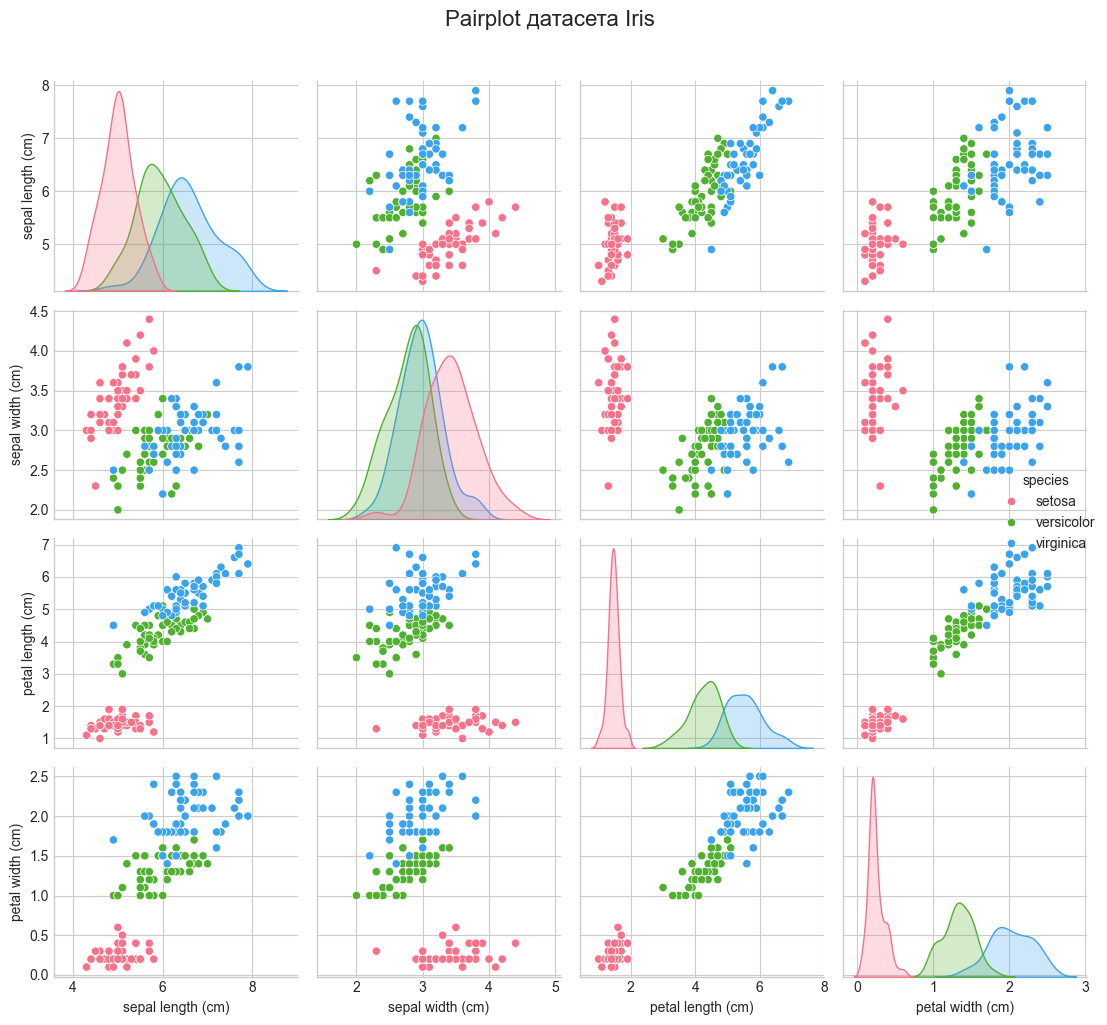


Pairplot сохранён в файл 'iris_pairplot.png'


In [4]:
# Построение pairplot для визуального анализа данных
plt.figure(figsize=(12, 10))
sns.pairplot(df, hue='species', palette='husl', diag_kind='kde')
plt.suptitle('Pairplot датасета Iris', y=1.02, fontsize=16)
plt.tight_layout()
plt.savefig('iris_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPairplot сохранён в файл 'iris_pairplot.png'")

### Выводы по визуальному анализу:
- Видна чёткая кластеризация видов Iris
- Лепестки (petal length/width) лучше всего разделяют классы
- Чашелистики (sepal length/width) имеют некоторое перекрытие между классами

## Задание 2: Логистическая регрессия для бинарной классификации

In [5]:
# Подготовка данных для бинарной классификации (Iris Versicolor vs Iris Virginica)
# Фильтруем только два класса
df_binary = df[df['species'].isin(['versicolor', 'virginica'])].copy()

# Преобразуем целевую переменную в числовой формат
df_binary['target'] = (df_binary['species'] == 'virginica').astype(int)

print(f"Размер бинарного датасета: {df_binary.shape}")
print(f"\nРаспределение классов:")
print(df_binary['species'].value_counts())

Размер бинарного датасета: (100, 6)

Распределение классов:
species
versicolor    50
virginica     50
setosa         0
Name: count, dtype: int64


In [6]:
# Выбор признаков и целевой переменной
# X - матрица признаков (4 признака Iris)
# y - целевая переменная (0 - versicolor, 1 - virginica)
X = df_binary[['sepal length (cm)', 'sepal width (cm)', 
                'petal length (cm)', 'petal width (cm)']]
y = df_binary['target']

# Разделение на обучающую и тестовую выборки
# train_test_split - разбиение данных (70% обучение, 30% тест)
# random_state=42 - для воспроизводимости результатов
# stratify=y - сохранение пропорций классов
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Обучающая выборка: {X_train.shape[0]} samples")
print(f"Тестовая выборка: {X_test.shape[0]} samples")

Обучающая выборка: 70 samples
Тестовая выборка: 30 samples


In [7]:
# Обучение модели логистической регрессии
# LogisticRegression - классическая модель для бинарной классификации
# random_state=42 - воспроизводимость
# max_iter=200 - максимальное количество итераций
model = LogisticRegression(random_state=42, max_iter=200)
# fit() - обучение модели на тренировочных данных
model.fit(X_train, y_train)

# Предсказания
# predict() - предсказание классов для новых данных
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Оценка качества
# accuracy_score - доля правильных предсказаний
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("=" * 50)
print("Результаты логистической регрессии")
print("=" * 50)
print(f"Точность на обучающей выборке: {train_accuracy:.4f}")
print(f"Точность на тестовой выборке: {test_accuracy:.4f}")

Результаты логистической регрессии
Точность на обучающей выборке: 0.9571
Точность на тестовой выборке: 0.9333



Classification Report (тестовая выборка):
              precision    recall  f1-score   support

  Versicolor       0.88      1.00      0.94        15
   Virginica       1.00      0.87      0.93        15

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



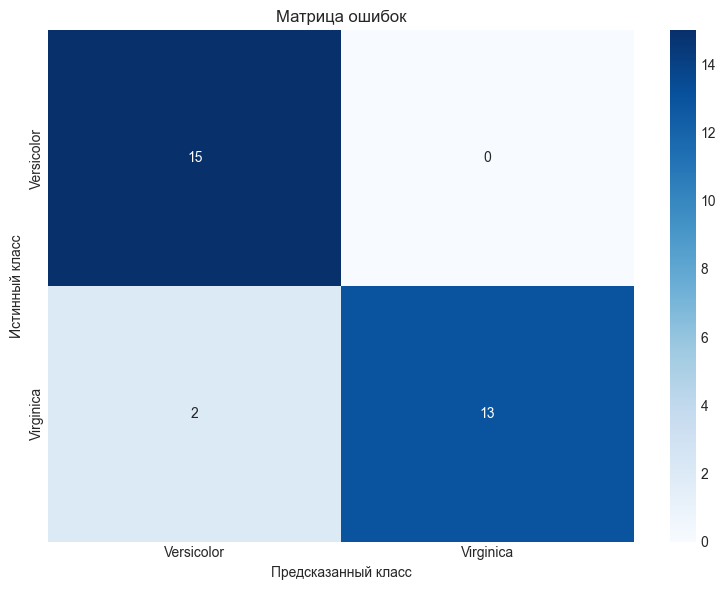

In [8]:
# Детальный отчёт по классификации
print("\nClassification Report (тестовая выборка):")
print(classification_report(y_test, y_test_pred, target_names=['Versicolor', 'Virginica']))

# Матрица ошибок
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Versicolor', 'Virginica'],
            yticklabels=['Versicolor', 'Virginica'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Задание 3: Демонстрация переобучения на линейной регрессии

### Выводы по логистической регрессии:
- Модель показывает высокую точность на обоих наборах данных
- Разница между точностью на обучающей и тестовой выборках минимальна
- Это свидетельствует о хорошей обобщающей способности модели

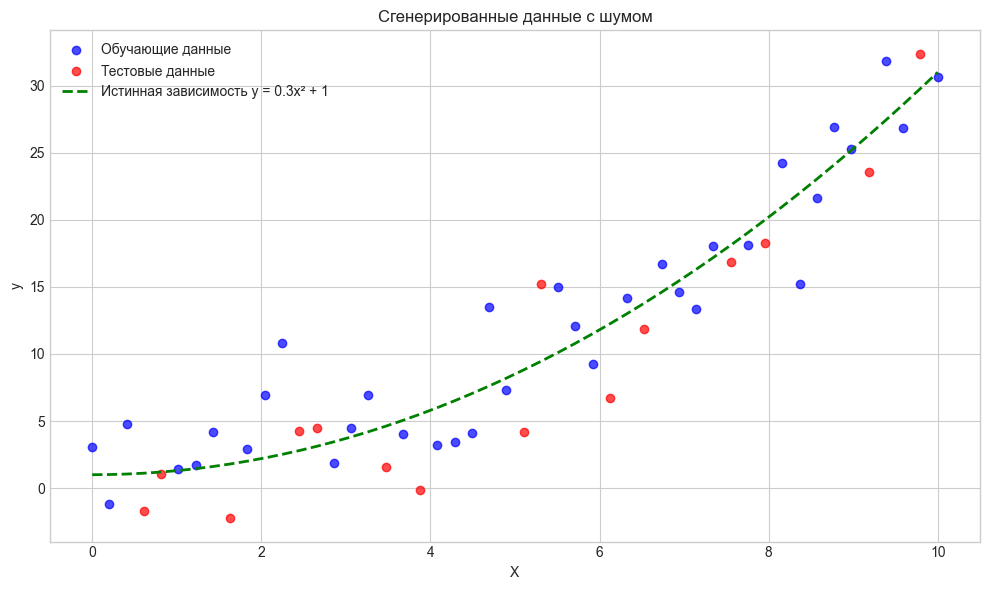

In [10]:
# Генерация синтетических данных с шумом
n_samples = 50
X_simple = np.linspace(0, 10, n_samples)

y_true = 0.3 * X_simple**2 + 1  # Истинная зависимость
# Добавление случайного шума (нормальное распределение)
y_noisy = y_true + np.random.normal(0, 3, n_samples)  # Добавляем шум

# Разделение на обучающую и тестовую выборки
# 70% данных для обучения, 30% для тестирования
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_simple, y_noisy, test_size=0.3, random_state=42
)

plt.figure(figsize=(10, 6))
# Визуализация данных
plt.scatter(X_train_reg, y_train_reg, color='blue', label='Обучающие данные', alpha=0.7)
plt.scatter(X_test_reg, y_test_reg, color='red', label='Тестовые данные', alpha=0.7)
# Истинная зависимость (зеленая пунктирная линия)
plt.plot(X_simple, y_true, color='green', linestyle='--', linewidth=2, label='Истинная зависимость y = 0.3x² + 1')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Сгенерированные данные с шумом')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('generated_data.png', dpi=150, bbox_inches='tight')
plt.show()

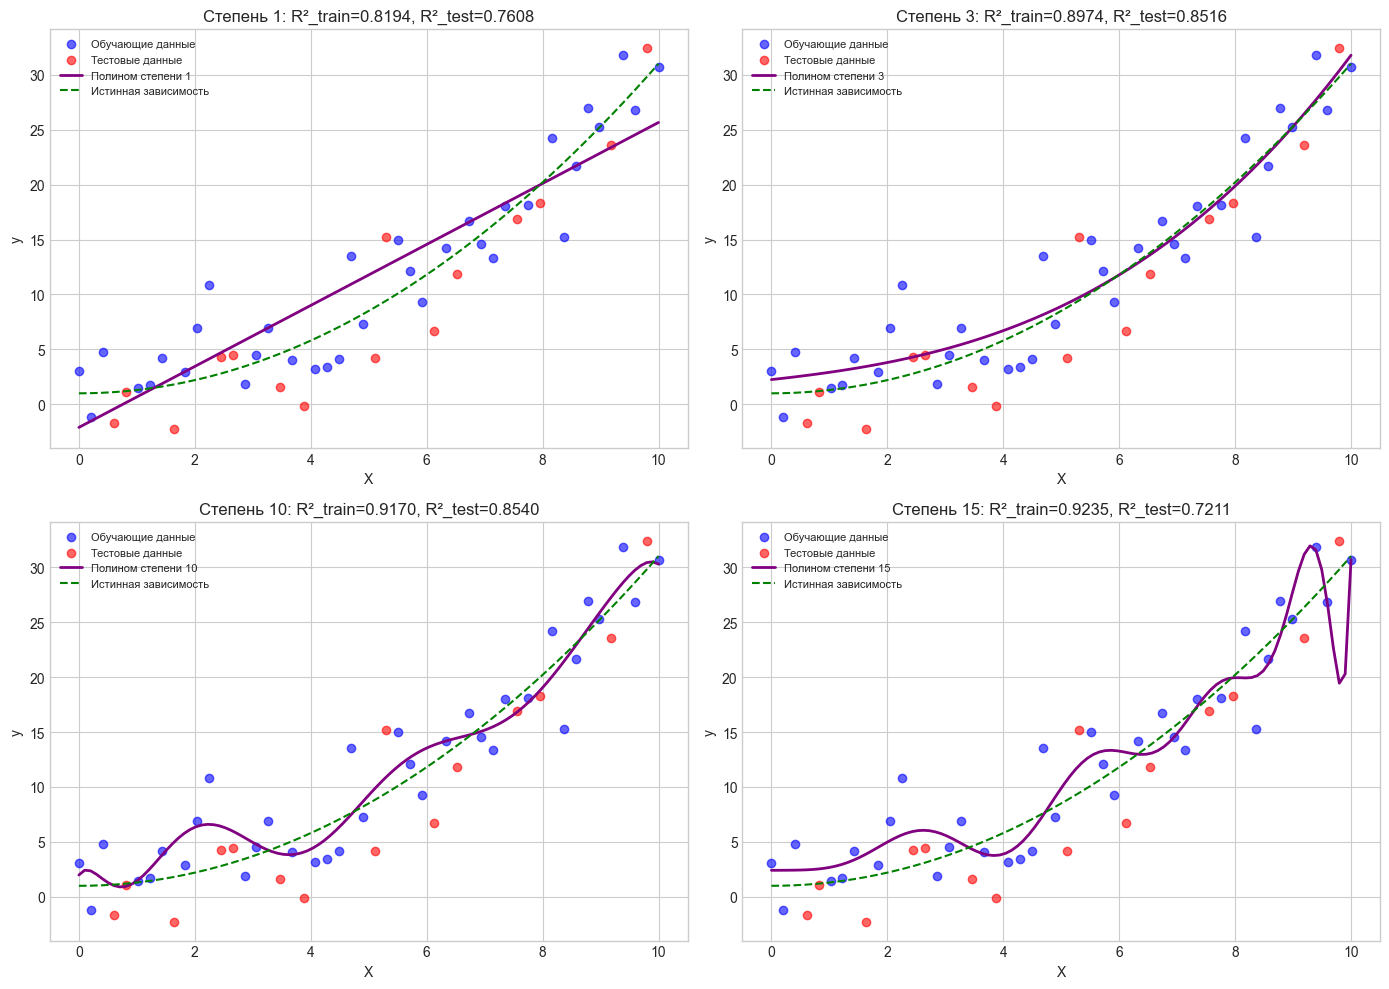


График переобучения сохранён в файл 'overfitting_demo.png'


In [11]:
# Обучение линейной регрессии разной сложности
degrees = [1, 3, 10, 15]  # Степени полинома
results = []

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, degree in enumerate(degrees):
    # Создание полиномиальных признаков
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train_reg.reshape(-1, 1))
    X_test_poly = poly.transform(X_test_reg.reshape(-1, 1))
    
    # Обучение модели
    model_reg = LinearRegression()
    model_reg.fit(X_train_poly, y_train_reg)
    
    # Предсказания
    y_train_pred_reg = model_reg.predict(X_train_poly)
    y_test_pred_reg = model_reg.predict(X_test_poly)
    
    # Вычисление R²
    r2_train = model_reg.score(X_train_poly, y_train_reg)
    r2_test = model_reg.score(X_test_poly, y_test_reg)
    
    results.append({
        'degree': degree,
        'r2_train': r2_train,
        'r2_test': r2_test
    })
    
    # Визуализация
    X_plot = np.linspace(0, 10, 100).reshape(-1, 1)
    X_plot_poly = poly.transform(X_plot)
    y_plot = model_reg.predict(X_plot_poly)
    
    axes[idx].scatter(X_train_reg, y_train_reg, color='blue', alpha=0.6, label='Обучающие данные')
    axes[idx].scatter(X_test_reg, y_test_reg, color='red', alpha=0.6, label='Тестовые данные')
    axes[idx].plot(X_plot, y_plot, color='purple', linewidth=2, label=f'Полином степени {degree}')
    axes[idx].plot(X_simple, y_true, color='green', linestyle='--', linewidth=1.5, label='Истинная зависимость')
    axes[idx].set_xlabel('X')
    axes[idx].set_ylabel('y')
    axes[idx].set_title(f'Степень {degree}: R²_train={r2_train:.4f}, R²_test={r2_test:.4f}')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True)

plt.tight_layout()
plt.savefig('overfitting_demo.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nГрафик переобучения сохранён в файл 'overfitting_demo.png'")

In [12]:
results_df = pd.DataFrame(results)
results_df['difference'] = results_df['r2_train'] - results_df['r2_test']
print('\n' + '=' * 60)
print('Comparison of models with different complexity')
print('=' * 60)
print(results_df.to_string(index=False))
print('\nConclusion:')
print('- Degree 1 (linear model): UNDERFITTING - too simple for nonlinear data')
print('- Degree 3-10: Good generalization')
print('- Degree 15: OVERFITTING - R2 on test lower than on train')



Comparison of models with different complexity
 degree  r2_train  r2_test  difference
      1  0.819440 0.760761    0.058679
      3  0.897410 0.851559    0.045851
     10  0.916955 0.853978    0.062977
     15  0.923471 0.721056    0.202414

Conclusion:
- Degree 1 (linear model): UNDERFITTING - too simple for nonlinear data
- Degree 3-10: Good generalization
- Degree 15: OVERFITTING - R2 on test lower than on train


## Выводы

В ходе лабораторной работы были выполнены следующие задачи:

1. **Загрузка и визуализация датасета Iris**: Построен pairplot, показывающий взаимосвязи между признаками и распределение классов.

2. **Логистическая регрессия для бинарной классификации**: Обучена модель для классификации Versicolor и Virginica с высокой точностью.

3. **Демонстрация переобучения**: Показано, как увеличение сложности модели приводит к переобучению - модель начинает описывать шум в данных вместо истинной зависимости.

**Ключевые наблюдения:**
- Простая модель (степень 1) показывает недообучение
- Модель средней сложности (степень 3-10) обеспечивает баланс между обучением и обобщением
- Слишком сложная модель (степень 15) переобучается - разница между R² на обучении и тесте увеличивается